In [4]:
print("hello world")

hello world


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [6]:
train_dataset = datasets.MNIST(
    root= "./data",
    train = True,
    download= True,
    transform=transforms.ToTensor()
)

train_loader = DataLoader(
    train_dataset,
    batch_size= 32,
    shuffle= True
)

In [7]:
data = list(train_loader)
print(data)

for i in range(len(data)):
    images , labels = data[i]
    break

[[tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 

torch.Size([32, 1, 28, 28])


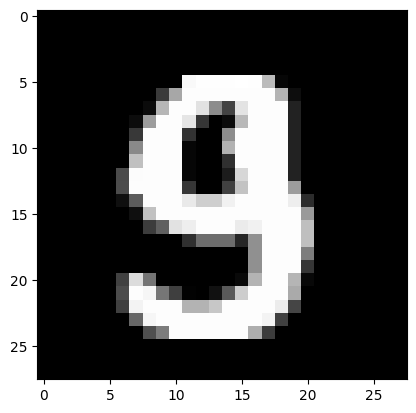

In [8]:
print(images.shape)
plt.imshow(images[1][0], cmap='gray')

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3
        )
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(13*13*8,10)
        
    def forward(self,x):
        x = self.conv1(x)
        print(x.shape)
        x = torch.relu(x)
        x = self.pool(x)
        print(x.shape)
        x = x.view(-1,13*13*8)
        print(x.shape)
        x = self.fc1(x)
        return x
    

In [10]:
print(torch.cuda.is_available())
torch.cuda.is_available()

True


True

In [11]:
device = torch.device("cuda")
model = CNN().to(device)
images = images.to(device)
output = model(images)

torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 1352])


In [12]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.01
) 

In [13]:
for epoch in range(5):
    for images , labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        loss = F.cross_entropy(output, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(loss.item())

torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 1352])
torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 1352])
torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 1352])
torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 1352])
torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 1352])
torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 1352])
torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 1352])
torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 1352])
torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 1352])
torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 1352])
torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 1352])
torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 1352])
torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 1

In [14]:
for i in range(len(data)):
    images , labels = data[i]
    break

images = images.to(device)
labels = labels.to(device)

In [15]:
output = model(images)
pred = output.argmax(1)

torch.Size([32, 8, 26, 26])
torch.Size([32, 8, 13, 13])
torch.Size([32, 1352])


In [16]:
print(pred[:10])

print(labels[:10])

tensor([3, 9, 5, 7, 2, 5, 2, 2, 7, 3], device='cuda:0')
tensor([3, 9, 5, 7, 2, 5, 2, 2, 2, 3], device='cuda:0')


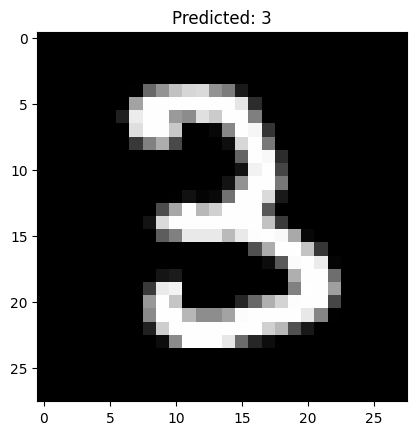

In [17]:
plt.imshow(images[0][0].cpu(), cmap='gray')

plt.title(f"Predicted: {pred[0].item()}")

plt.show()

In [18]:
acc = (pred == labels).float().mean()

print(acc)

tensor(0.9688, device='cuda:0')


## Try your own image

In [44]:
from PIL import Image
import torchvision.transforms as transforms

img = Image.open("test.png").convert("L")

transform = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.ToTensor()
])

x = transform(img)
print(x.shape)
x

torch.Size([1, 28, 28])


tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [45]:
x = x.unsqueeze(0)

In [46]:
x = x.to(device)

output = model(x)

pred = output.argmax(1)

print(pred.item())

torch.Size([1, 8, 26, 26])
torch.Size([1, 8, 13, 13])
torch.Size([1, 1352])
7
